In [77]:
import sys
sys.path.insert(0, '..')

import json, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
TIER_COLORS = {0: '#a8a8a8', 1: '#DD8452', 2: '#4C72B0'}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
def load_scan(directory):
    files = sorted(glob.glob(str(ROOT / directory / '*.json')))
    by_qid, paths = {}, {}
    for f in files:
        d = json.load(open(f))
        qid = int(d['question_id'])
        if qid not in by_qid or f > paths[qid]:
            by_qid[qid] = d
            paths[qid] = f
    return by_qid

gpqa_raw = load_scan('results/mas/gpqa_subset_scan')
hb_raw = load_scan('results/mas/hiddenbench_subset_scan')
print(f'GPQA: {len(gpqa_raw)} | HiddenBench: {len(hb_raw)}')

GPQA: 198 | HiddenBench: 65


In [87]:
def votes_at(rep, t):
    return [a['vote'] for a in rep['trajectory'][t]['phase_b']]

def count_flips(rep):
    traj = rep['trajectory']
    total = 0
    for ag in range(len(traj[0]['phase_b'])):
        for t in range(1, len(traj)):
            if traj[t - 1]['phase_b'][ag]['vote'] != traj[t]['phase_b'][ag]['vote']:
                total += 1
    return total

def question_stats(d):
    reps = d['repetitions']
    gt = d['ground_truth']
    T_max = d['T']
    rep_stats, final_majorities = [], []
    for rep in reps:
        T = len(rep['trajectory'])
        v0 = votes_at(rep, 0)
        v_final = votes_at(rep, T - 1)
        majority = max(set(v_final), key=v_final.count)
        final_majorities.append(majority)
        rep_stats.append({
            'initial_unanimous': len(set(v0)) == 1,
            'initial_correct': sum(v == gt for v in v0) / len(v0),
            'flips': count_flips(rep),
            'trajectory_len': T,
            'consensus_reached': len(set(v_final)) == 1,
            'system_correct': majority == gt,
            'never_converged': T == T_max and len(set(v_final)) > 1,
        })
    return {
        'qid': int(d['question_id']),
        'gt': gt,
        'n_reps': len(rep_stats),
        'initial_unanimous_rate': float(np.mean([r['initial_unanimous'] for r in rep_stats])),
        'mean_flips': float(np.mean([r['flips'] for r in rep_stats])),
        'mean_trajectory_len': float(np.mean([r['trajectory_len'] for r in rep_stats])),
        'consensus_reached_rate': float(np.mean([r['consensus_reached'] for r in rep_stats])),
        'initial_correct_rate': float(np.mean([r['initial_correct'] for r in rep_stats])),
        'final_correct_rate': float(np.mean([r['system_correct'] for r in rep_stats])),
        'outcome_variance': len(set(final_majorities)) > 1,
        'never_converged_rate': float(np.mean([r['never_converged'] for r in rep_stats])),
    }

def assign_tier(row):
    if row['initial_unanimous_rate'] == 1.0 and row['mean_flips'] == 0.0:
        return 0
    if row['mean_trajectory_len'] <= 4.0:
        return 1
    return 2

In [88]:
gpqa_df = pd.DataFrame([question_stats(d) for d in gpqa_raw.values()])
gpqa_df['tier'] = gpqa_df.apply(assign_tier, axis=1)
gpqa_df = gpqa_df.sort_values('qid').reset_index(drop=True)

hb_df = pd.DataFrame([question_stats(d) for d in hb_raw.values()])
hb_df['tier'] = hb_df.apply(assign_tier, axis=1)
hb_df = hb_df.sort_values('qid').reset_index(drop=True)

for name, df in [('GPQA', gpqa_df), ('HiddenBench', hb_df)]:
    counts = df['tier'].value_counts().sort_index()
    total = len(df)
    print()
    print(f'{name} ({total} questions):')
    for t, n in counts.items():
        print(f'  Tier {t}: {n} ({100 * n / total:.1f}%)')


GPQA (198 questions):
  Tier 0: 44 (22.2%)
  Tier 1: 34 (17.2%)
  Tier 2: 120 (60.6%)

HiddenBench (65 questions):
  Tier 0: 4 (6.2%)
  Tier 1: 3 (4.6%)
  Tier 2: 58 (89.2%)


## Tier Distribution

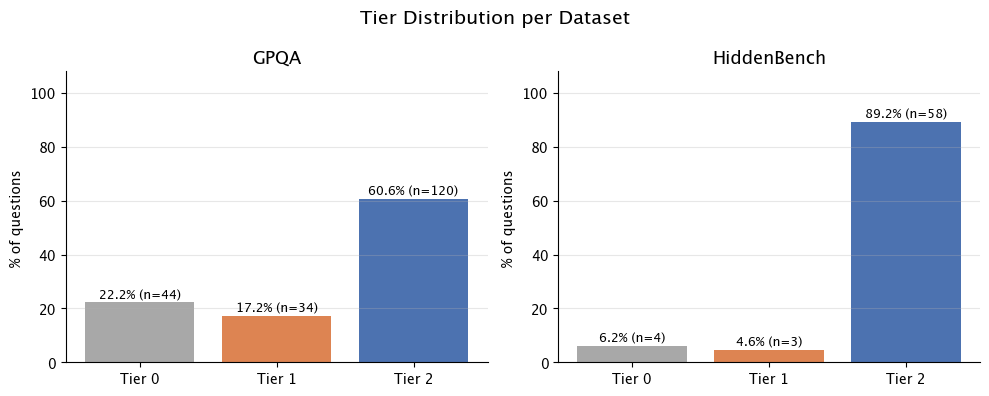

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    counts = df['tier'].value_counts().sort_index()
    pcts = 100 * counts / len(df)
    bars = ax.bar(
        [f'Tier {t}' for t in counts.index],
        pcts.values,
        color=[TIER_COLORS[t] for t in counts.index],
    )
    for bar, pct, n in zip(bars, pcts.values, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{pct:.1f}% (n={n})', ha='center', va='bottom', fontsize=9)
    ax.set_title(name, fontsize=13)
    ax.set_ylabel('% of questions')
    ax.set_ylim(0, 108)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Tier Distribution per Dataset', fontsize=14)
plt.tight_layout()
plt.show()

## Per-Tier Stats

In [16]:
def tier_summary(df):
    rows = []
    for tier in sorted(df['tier'].unique()):
        sub = df[df['tier'] == tier]
        rows.append({
            'tier': tier,
            'n': len(sub),
            'pct_%': round(100 * len(sub) / len(df), 1),
            'init_unanimous': round(sub['initial_unanimous_rate'].mean(), 2),
            'mean_flips': round(sub['mean_flips'].mean(), 2),
            'mean_traj_len': round(sub['mean_trajectory_len'].mean(), 2),
            'consensus_rate': round(sub['consensus_reached_rate'].mean(), 2),
            'initial_acc': round(sub['initial_correct_rate'].mean(), 2),
            'final_acc': round(sub['final_correct_rate'].mean(), 2),
            'outcome_var_rate': round(float(sub['outcome_variance'].mean()), 2),
            'never_conv_rate': round(sub['never_converged_rate'].mean(), 2),
        })
    return pd.DataFrame(rows).set_index('tier')

print('GPQA')
display(tier_summary(gpqa_df))
print()
print('HiddenBench')
display(tier_summary(hb_df))

GPQA


,n,pct_%,init_unanimous,mean_flips,mean_traj_len,consensus_rate,initial_acc,final_acc,outcome_var_rate,never_conv_rate
tier,,,,,,,,,,
0,44,22.2,1.00,0.00,4.00,1.0,0.84,0.84,0.00,0.0
1,34,17.2,0.45,0.76,4.00,1.0,0.59,0.69,0.21,0.0
2,120,60.6,0.14,3.61,5.58,1.0,0.40,0.46,0.63,0.0



HiddenBench


,n,pct_%,init_unanimous,mean_flips,mean_traj_len,consensus_rate,initial_acc,final_acc,outcome_var_rate,never_conv_rate
tier,,,,,,,,,,
0,4,6.2,1.00,0.00,4.00,1.0,0.00,0.00,0.00,0.0
1,3,4.6,0.33,0.67,4.00,1.0,0.11,0.00,0.00,0.0
2,58,89.2,0.11,4.57,7.32,0.9,0.16,0.32,0.69,0.0


## Trajectory Length by Tier

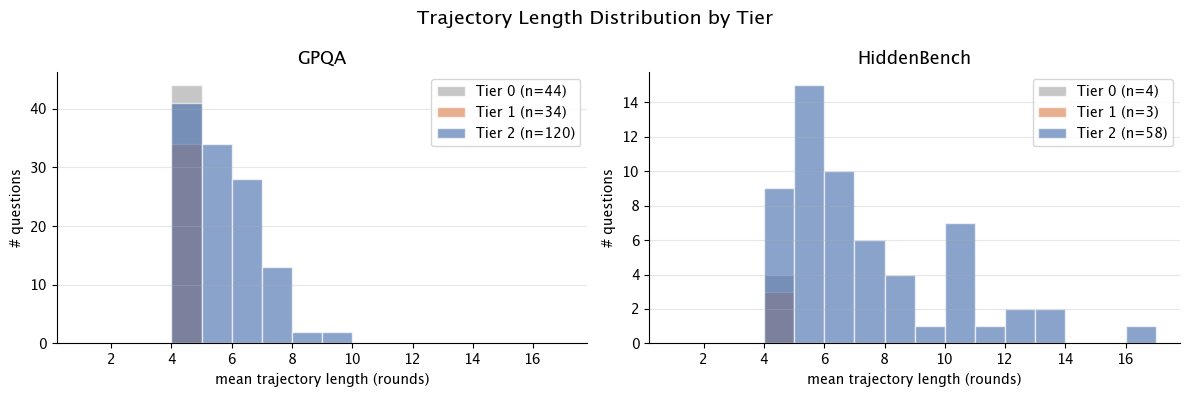

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    for tier in sorted(df['tier'].unique()):
        sub = df[df['tier'] == tier]['mean_trajectory_len']
        ax.hist(sub, bins=range(1, 18), alpha=0.65,
                color=TIER_COLORS[tier], label=f'Tier {tier} (n={len(sub)})',
                edgecolor='white')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('mean trajectory length (rounds)')
    ax.set_ylabel('# questions')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Trajectory Length Distribution by Tier', fontsize=14)
plt.tight_layout()
plt.show()

## Accuracy: Round 0 vs Final by Tier

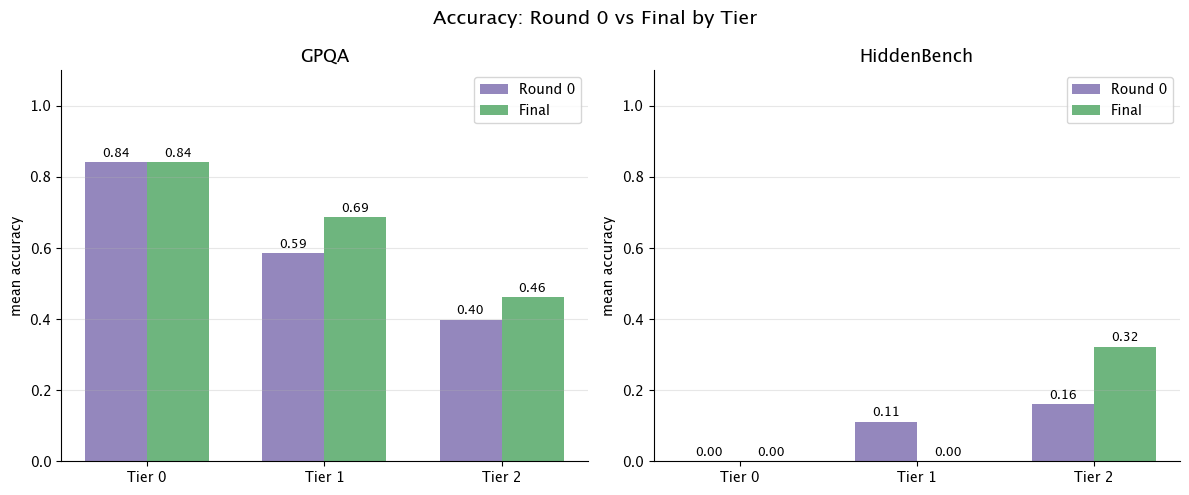

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    tiers = sorted(df['tier'].unique())
    x = np.arange(len(tiers))
    w = 0.35
    init_means = [df[df['tier'] == t]['initial_correct_rate'].mean() for t in tiers]
    final_means = [df[df['tier'] == t]['final_correct_rate'].mean() for t in tiers]
    ax.bar(x - w / 2, init_means, w, label='Round 0', color='#8172B2', alpha=0.85)
    ax.bar(x + w / 2, final_means, w, label='Final', color='#55A868', alpha=0.85)
    for xi, (iv, fv) in enumerate(zip(init_means, final_means)):
        ax.text(xi - w / 2, iv + 0.01, f'{iv:.2f}', ha='center', va='bottom', fontsize=9)
        ax.text(xi + w / 2, fv + 0.01, f'{fv:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Tier {t}' for t in tiers])
    ax.set_ylabel('mean accuracy')
    ax.set_ylim(0, 1.1)
    ax.set_title(name, fontsize=13)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Accuracy: Round 0 vs Final by Tier', fontsize=14)
plt.tight_layout()
plt.show()

## Tier 2 Deep Dive

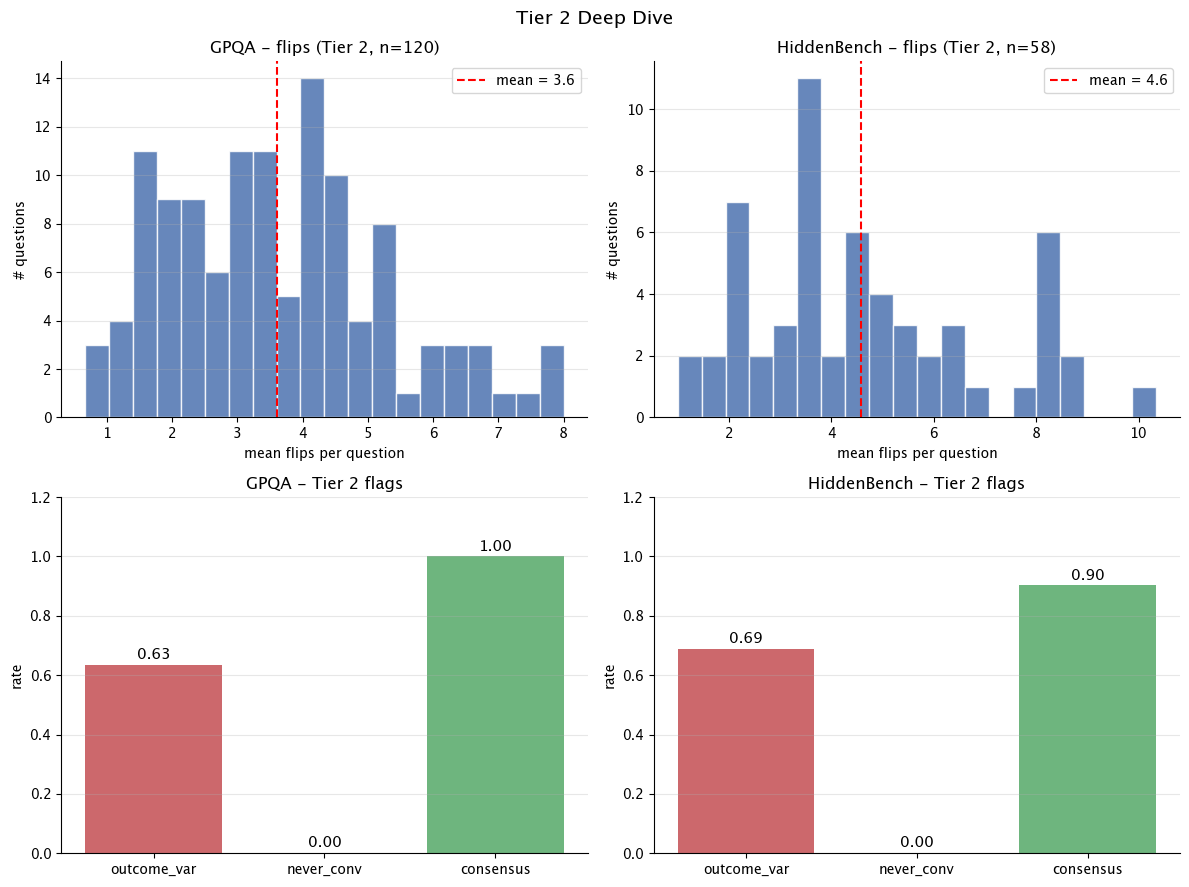

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for col, (name, df) in enumerate([('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    t2 = df[df['tier'] == 2]

    ax = axes[0, col]
    mean_flips = t2['mean_flips'].mean()
    ax.hist(t2['mean_flips'], bins=20, color=TIER_COLORS[2], edgecolor='white', alpha=0.85)
    ax.axvline(mean_flips, color='red', linestyle='--', label=f'mean = {mean_flips:.1f}')
    ax.set_title(f'{name} - flips (Tier 2, n={len(t2)})', fontsize=12)
    ax.set_xlabel('mean flips per question')
    ax.set_ylabel('# questions')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1, col]
    labels = ['outcome_var', 'never_conv', 'consensus']
    values = [
        float(t2['outcome_variance'].mean()),
        float(t2['never_converged_rate'].mean()),
        float(t2['consensus_reached_rate'].mean()),
    ]
    colors = ['#C44E52', '#DD8452', '#55A868']
    bars = ax.bar(labels, values, color=colors, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=11)
    ax.set_title(f'{name} - Tier 2 flags', fontsize=12)
    ax.set_ylabel('rate')
    ax.set_ylim(0, 1.2)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Tier 2 Deep Dive', fontsize=14)
plt.tight_layout()
plt.show()

## Tier 2 Question IDs

In [20]:
gpqa_t2 = sorted(gpqa_df[gpqa_df['tier'] == 2]['qid'].tolist())
hb_t2 = sorted(hb_df[hb_df['tier'] == 2]['qid'].tolist())

print(f'GPQA Tier 2 ({len(gpqa_t2)} questions): {gpqa_t2}')
print()
print(f'HiddenBench Tier 2 ({len(hb_t2)} questions): {hb_t2}')

GPQA Tier 2 (120 questions): [1, 3, 5, 6, 7, 8, 9, 10, 12, 14, 15, 17, 18, 21, 23, 24, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 41, 42, 44, 47, 48, 50, 51, 52, 53, 54, 55, 56, 60, 61, 63, 64, 66, 67, 69, 70, 71, 73, 75, 79, 80, 81, 84, 85, 86, 88, 90, 91, 92, 94, 95, 98, 99, 102, 104, 109, 111, 113, 114, 115, 117, 118, 120, 121, 123, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 138, 139, 140, 141, 143, 144, 145, 146, 147, 149, 152, 154, 155, 157, 159, 162, 163, 164, 166, 168, 169, 170, 172, 173, 175, 179, 180, 182, 183, 185, 186, 187, 189, 194]

HiddenBench Tier 2 (58 questions): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 64]


## Tier 2 Closer Look

In [21]:
def init_diversity(d):
    return float(np.mean([len(set(votes_at(rep, 0))) for rep in d['repetitions']]))

for raw, df in [(gpqa_raw, gpqa_df), (hb_raw, hb_df)]:
    df['initial_vote_diversity'] = [init_diversity(raw[qid]) for qid in df['qid']]

for name, df in [('GPQA', gpqa_df), ('HiddenBench', hb_df)]:
    t2 = df[df['tier'] == 2]
    always  = (t2['consensus_reached_rate'] == 1.0).sum()
    partial = ((t2['consensus_reached_rate'] > 0) & (t2['consensus_reached_rate'] < 1.0)).sum()
    never   = (t2['consensus_reached_rate'] == 0.0).sum()
    print(f'{name} Tier 2 (n={len(t2)}):')
    print(f'  always converge:     {always} ({100*always/len(t2):.1f}%)')
    print(f'  partial convergence: {partial} ({100*partial/len(t2):.1f}%)')
    print(f'  never converge:      {never} ({100*never/len(t2):.1f}%)')
    print()

GPQA Tier 2 (n=120):
  always converge:     120 (100.0%)
  partial convergence: 0 (0.0%)
  never converge:      0 (0.0%)

HiddenBench Tier 2 (n=58):
  always converge:     45 (77.6%)
  partial convergence: 12 (20.7%)
  never converge:      1 (1.7%)



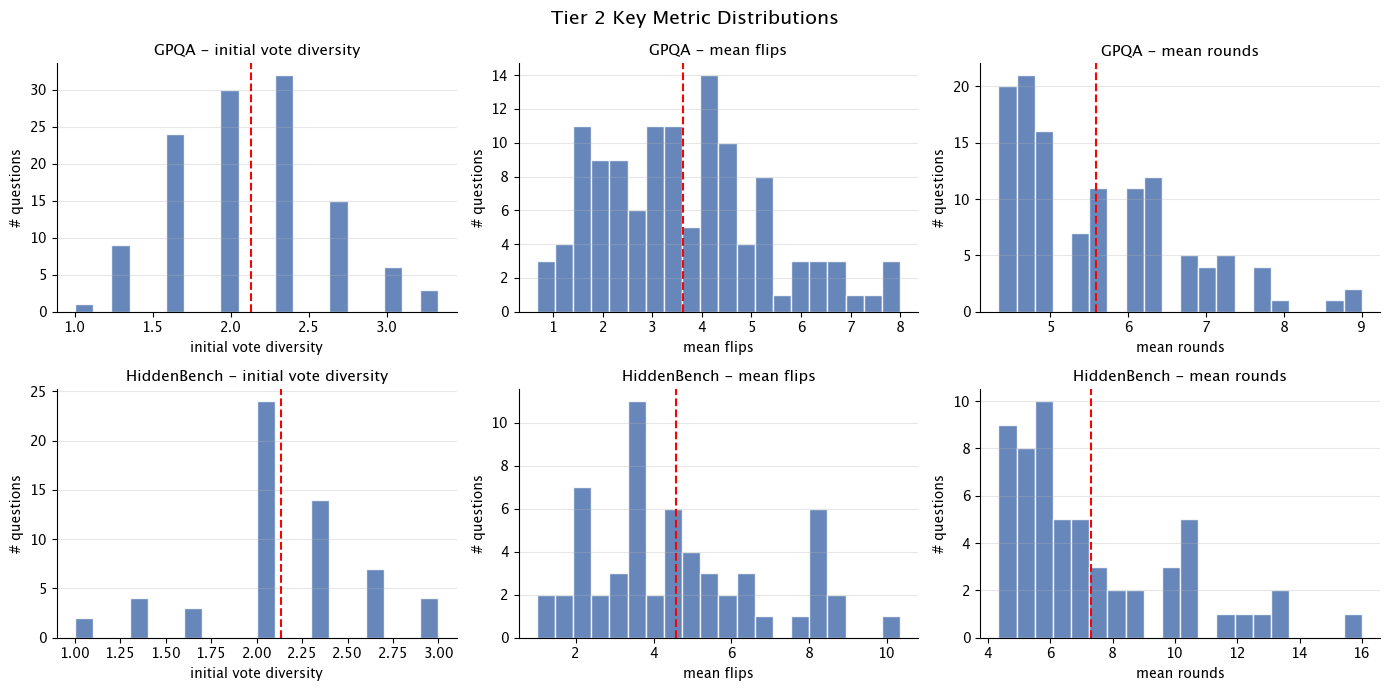

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
metrics = [
    ('initial_vote_diversity', 'initial vote diversity'),
    ('mean_flips', 'mean flips'),
    ('mean_trajectory_len', 'mean rounds'),
]

for row, (name, df) in enumerate([('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    t2 = df[df['tier'] == 2]
    for col, (metric, label) in enumerate(metrics):
        ax = axes[row, col]
        ax.hist(t2[metric], bins=20, color=TIER_COLORS[2], edgecolor='white', alpha=0.85)
        ax.axvline(t2[metric].mean(), color='red', linestyle='--', linewidth=1.5)
        ax.set_title(f'{name} - {label}', fontsize=11)
        ax.set_xlabel(label)
        ax.set_ylabel('# questions')
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle('Tier 2 Key Metric Distributions', fontsize=14)
plt.tight_layout()
plt.show()

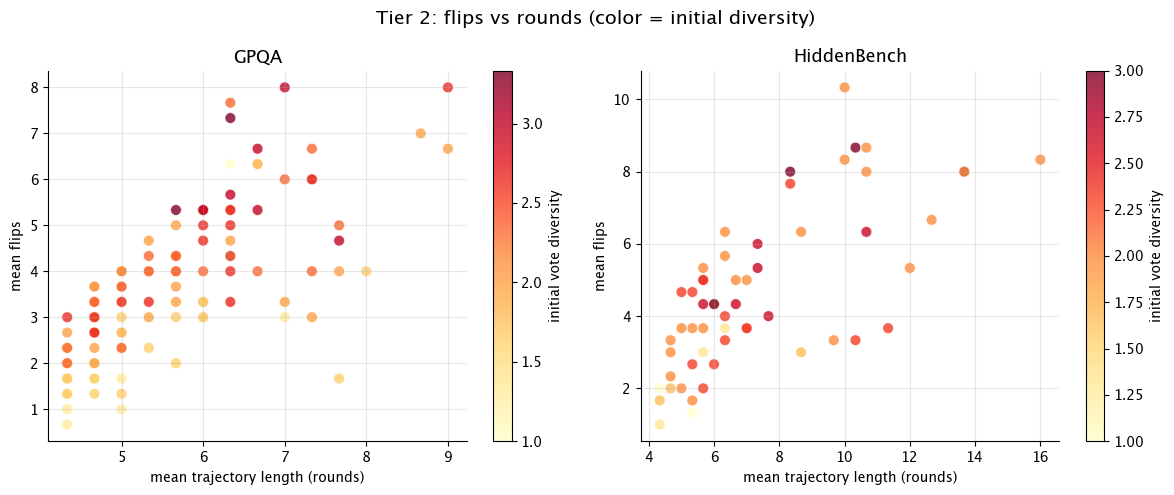

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    t2 = df[df['tier'] == 2]
    sc = ax.scatter(
        t2['mean_trajectory_len'],
        t2['mean_flips'],
        c=t2['initial_vote_diversity'],
        cmap='YlOrRd',
        s=60, alpha=0.8, edgecolors='white', linewidths=0.5,
    )
    plt.colorbar(sc, ax=ax, label='initial vote diversity')
    ax.set_xlabel('mean trajectory length (rounds)')
    ax.set_ylabel('mean flips')
    ax.set_title(name, fontsize=13)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Tier 2: flips vs rounds (color = initial diversity)', fontsize=14)
plt.tight_layout()
plt.show()

## Tier 2 Interestingness Score

In [24]:
for name, df in [('GPQA', gpqa_df), ('HiddenBench', hb_df)]:
    t2_mask = df['tier'] == 2
    t2 = df[t2_mask].copy()
    t2['score'] = (
        t2['mean_flips'].rank(pct=True) +
        t2['mean_trajectory_len'].rank(pct=True) +
        t2['initial_vote_diversity'].rank(pct=True)
    ) / 3
    df.loc[t2.index, 'score'] = t2['score']

    cols = ['qid', 'initial_vote_diversity', 'mean_flips', 'mean_trajectory_len',
            'consensus_reached_rate', 'outcome_variance', 'initial_correct_rate', 'final_correct_rate', 'score']
    print(f'{name} top 15 Tier 2 by score:')
    display(t2.sort_values('score', ascending=False)[cols].head(15).round(2))
    print()

print('--- High-score question IDs (score >= 0.5) ---')
for name, df in [('GPQA', gpqa_df), ('HiddenBench', hb_df)]:
    top = df[(df['tier'] == 2) & (df['score'] >= 0.5)]
    print(f'{name} ({len(top)}): {sorted(top["qid"].tolist())}')

GPQA top 15 Tier 2 by score:


,qid,initial_vote_diversity,mean_flips,mean_trajectory_len,consensus_reached_rate,outcome_variance,initial_correct_rate,final_correct_rate,score
194,194,2.67,8.00,9.00,1.0,True,0.33,0.67,0.95
42,42,3.00,8.00,7.00,1.0,True,0.50,0.67,0.94
125,125,3.00,6.67,6.67,1.0,True,0.25,0.33,0.92
186,186,3.33,7.33,6.33,1.0,False,0.42,0.00,0.91
51,51,2.67,6.00,7.33,1.0,True,0.25,0.00,0.89
95,95,3.00,4.67,7.67,1.0,True,0.25,0.00,0.89
21,21,3.00,5.33,6.67,1.0,True,0.42,0.33,0.88
144,144,3.00,5.67,6.33,1.0,True,0.50,0.67,0.87
147,147,2.33,6.67,7.33,1.0,True,0.08,0.00,0.85
36,36,2.33,6.00,7.33,1.0,True,0.08,0.00,0.83



HiddenBench top 15 Tier 2 by score:


,qid,initial_vote_diversity,mean_flips,mean_trajectory_len,consensus_reached_rate,outcome_variance,initial_correct_rate,final_correct_rate,score
36,36,3.00,8.00,13.67,0.67,False,0.33,1.00,0.95
20,20,3.00,8.67,10.33,0.67,False,0.25,1.00,0.93
40,40,3.00,8.00,8.33,1.00,True,0.25,0.33,0.86
26,26,2.67,6.33,10.67,1.00,False,0.33,1.00,0.85
53,53,2.00,8.33,16.00,0.00,False,0.00,0.00,0.77
21,21,2.67,6.00,7.33,1.00,False,0.17,1.00,0.77
34,34,2.33,7.67,8.33,1.00,True,0.17,0.00,0.75
30,30,2.67,5.33,7.33,1.00,False,0.58,1.00,0.75
37,37,2.00,8.00,13.67,0.33,True,0.00,0.00,0.74
46,46,2.00,8.67,10.67,1.00,True,0.08,0.67,0.74



--- High-score question IDs (score >= 0.5) ---
GPQA (59): [3, 6, 7, 8, 15, 21, 23, 27, 28, 33, 34, 36, 42, 44, 51, 52, 53, 61, 63, 67, 71, 73, 75, 80, 84, 90, 92, 94, 95, 102, 104, 109, 115, 117, 118, 121, 125, 126, 127, 129, 136, 139, 143, 144, 145, 147, 149, 154, 155, 159, 166, 173, 175, 179, 180, 186, 187, 189, 194]
HiddenBench (33): [0, 2, 3, 4, 8, 12, 13, 14, 15, 16, 18, 20, 21, 24, 25, 26, 28, 30, 31, 34, 35, 36, 37, 40, 42, 45, 46, 51, 52, 53, 55, 57, 64]


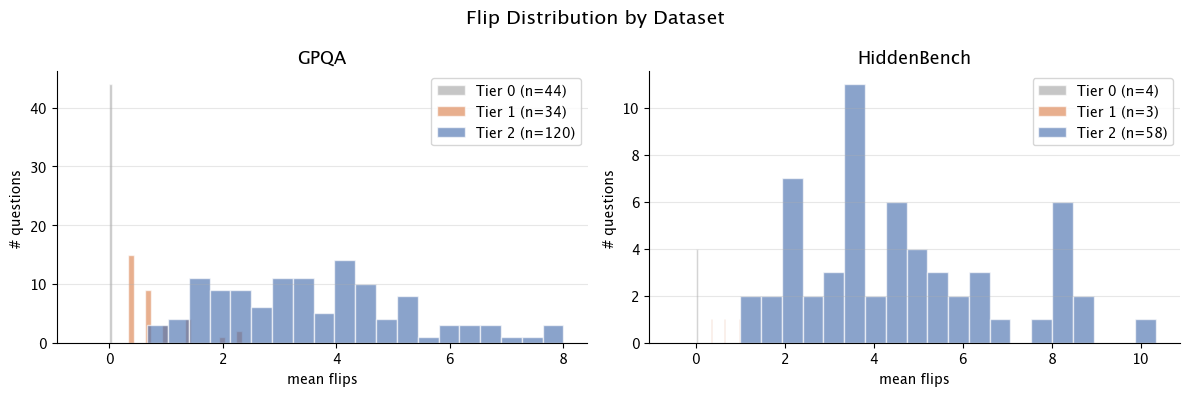

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    for tier in sorted(df['tier'].unique()):
        sub = df[df['tier'] == tier]['mean_flips']
        ax.hist(sub, bins=20, alpha=0.65, color=TIER_COLORS[tier],
                label=f'Tier {tier} (n={len(sub)})', edgecolor='white')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('mean flips')
    ax.set_ylabel('# questions')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Flip Distribution by Dataset', fontsize=14)
plt.tight_layout()
plt.show()


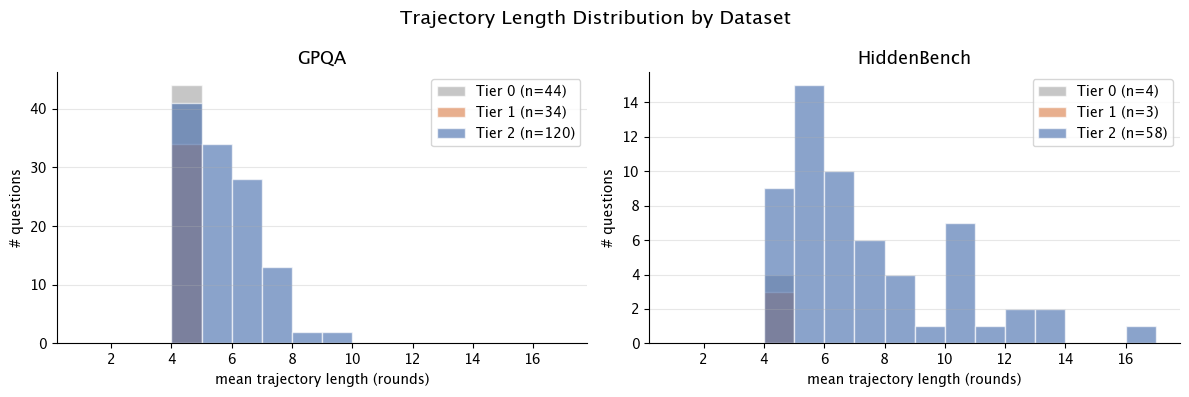

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    for tier in sorted(df['tier'].unique()):
        sub = df[df['tier'] == tier]['mean_trajectory_len']
        ax.hist(sub, bins=range(1, 18), alpha=0.65, color=TIER_COLORS[tier],
                label=f'Tier {tier} (n={len(sub)})', edgecolor='white')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('mean trajectory length (rounds)')
    ax.set_ylabel('# questions')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Trajectory Length Distribution by Dataset', fontsize=14)
plt.tight_layout()
plt.show()


In [27]:
def entropy(votes, n_options=None):
    values, counts = np.unique(votes, return_counts=True)
    p = counts / counts.sum()
    k = n_options if n_options else len(values)
    return -np.sum(p * np.log(p)) / np.log(k)

In [37]:
entropy(["A", "D", "B", "D"], n_options=3)

np.float64(0.946394630357186)

dataset      converged
GPQA         True         594
HiddenBench  False          6
             True         189
dtype: int64


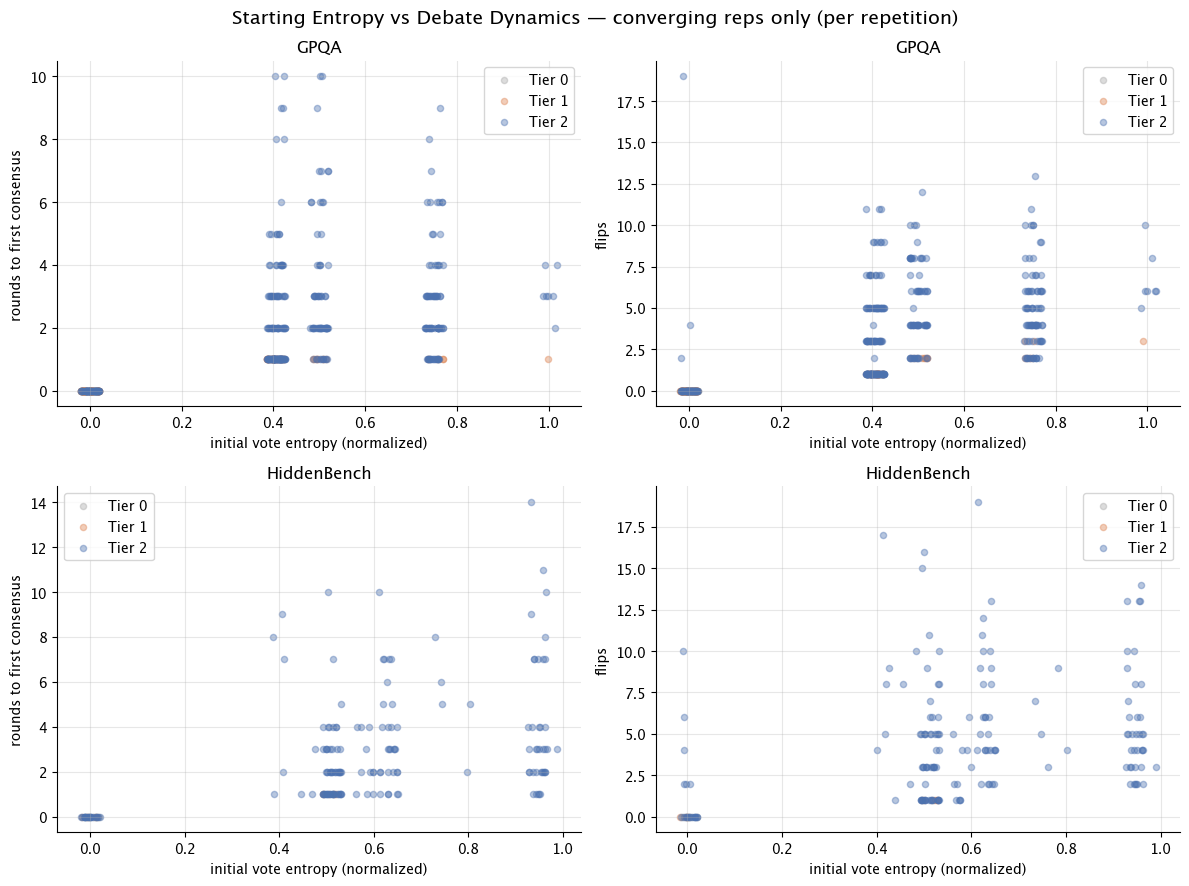

In [46]:
def vote_entropy(votes, n_options):
    values, counts = np.unique(votes, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p)) / np.log(n_options)

tier_lookup = {
    'GPQA': dict(zip(gpqa_df['qid'], gpqa_df['tier'])),
    'HiddenBench': dict(zip(hb_df['qid'], hb_df['tier'])),
}

def rounds_to_first_consensus(rep):
    for t, round_data in enumerate(rep['trajectory']):
        if len(set(votes_at(rep, t))) == 1:
            return t
    return None

records = []
for dataset, raw in [('GPQA', gpqa_raw), ('HiddenBench', hb_raw)]:
    for qid, d in raw.items():
        n_options = len(d['options'])
        for i, rep in enumerate(d['repetitions']):
            v0 = votes_at(rep, 0)
            rtc = rounds_to_first_consensus(rep)
            records.append({
                'dataset': dataset,
                'qid': qid,
                'rep': i,
                'tier': tier_lookup[dataset][qid],
                'entropy': vote_entropy(v0, n_options),
                'rounds_to_consensus': rtc,
                'flips': count_flips(rep),
                'converged': rtc is not None,
            })

reps_df = pd.DataFrame(records)
print(reps_df.groupby(['dataset', 'converged']).size())


fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for row, dataset in enumerate(['GPQA', 'HiddenBench']):
    sub = reps_df[(reps_df['dataset'] == dataset) & reps_df['converged']]
    for col, (metric, label) in enumerate([
        ('rounds_to_consensus', 'rounds to first consensus'),
        ('flips', 'flips'),
    ]):
        ax = axes[row, col]
        for tier in sorted(sub['tier'].unique()):
            t = sub[sub['tier'] == tier]
            jitter = np.random.uniform(-0.02, 0.02, len(t))
            ax.scatter(t['entropy'] + jitter, t[metric],
                       alpha=0.4, s=20, color=TIER_COLORS[tier], label=f'Tier {tier}')
        ax.set_xlabel('initial vote entropy (normalized)')
        ax.set_ylabel(label)
        ax.set_title(dataset, fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle('Starting Entropy vs Debate Dynamics — converging reps only (per repetition)', fontsize=14)
plt.tight_layout()
plt.show()


In [52]:
from scipy import stats

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

rows = []
for dataset in ['GPQA', 'HiddenBench']:
    for subset_label, tier_filter in [('all tiers', None), ('tier 2 only', 2)]:
        sub = reps_df[(reps_df['dataset'] == dataset) & reps_df['converged']]
        if tier_filter is not None:
            sub = sub[sub['tier'] == tier_filter]
        for metric in ['rounds_to_consensus', 'flips']:
            r_p, p_p = stats.pearsonr(sub['entropy'], sub[metric])
            r_s, p_s = stats.spearmanr(sub['entropy'], sub[metric])
            rows.append({
                'dataset': dataset,
                'subset': subset_label,
                'metric': metric,
                'n': len(sub),
                'pearson_r': round(r_p, 3),
                'pearson_p': f'{p_p:.3e} {sig_stars(p_p)}',
                'spearman_r': round(r_s, 3),
                'spearman_p': f'{p_s:.3e} {sig_stars(p_s)}',
            })

display(pd.DataFrame(rows).set_index(['dataset', 'subset', 'metric']))


n  pearson_r      pearson_p  \
dataset     subset      metric                                               
GPQA        all tiers   rounds_to_consensus  594      0.607  3.780e-61 ***   
                        flips                594      0.665  5.645e-77 ***   
            tier 2 only rounds_to_consensus  360      0.419  8.977e-17 ***   
                        flips                360      0.493  2.058e-23 ***   
HiddenBench all tiers   rounds_to_consensus  189      0.535  2.334e-15 ***   
                        flips                189      0.423  1.385e-09 ***   
            tier 2 only rounds_to_consensus  168      0.466  1.934e-10 ***   
                        flips                168      0.316  3.064e-05 ***   

                                             spearman_r      spearman_p  
dataset     subset      metric                                           
GPQA        all tiers   rounds_to_consensus       0.851  7.960e-168 ***  
                        flips                     0.869  5.157e-183 ***  
            tier 2 only rounds_to_consensus       0.561   2.749e-31 ***  
                        flips                     0.614   1.286e-38 ***  
HiddenBench all tiers   rounds_to_consensus       0.644   1.716e-23 ***  
                        flips                     0.519   2.104e-14 ***  
            tier 2 only rounds_to_consensus       0.526   2.445e-13 ***  
                        flips                     0.368   9.338e-07 ***

The correction mattered for all tiers. GPQA all-tiers Spearman jumped from 0.615 (old trajectory_len) to 0.851. Reason: Tier 0 questions now correctly show rounds_to_consensus = 0 (unanimous from round 0) instead of 3 (the u=3 tail). The anchor at (entropy=0, rounds=0) is now exact, giving a tighter rank correlation.

Tier 2 only is the honest number. All-tiers is still inflated by Tier 0 pulling the line — every Tier 0 point is a perfect (entropy=0, rounds=0, flips=0) anchor. Tier 2 only removes that free boost. Those are the correlations that actually tell you something: starting entropy explains a moderate share of debate dynamics, not a dominant one.

GPQA is more predictable than HiddenBench. Within Tier 2:

GPQA: entropy → flips r=0.614, entropy → rounds r=0.561 — consistent, both moderate-strong
HiddenBench: entropy → rounds r=0.526 but entropy → flips drops to r=0.368
That asymmetry in HiddenBench is meaningful. Starting diversity predicts how long the debate runs reasonably well, but predicts how many flips much less. The hidden information structure creates flip dynamics that are independent of who started agreeing or disagreeing — agents can start unanimous but flip later once they process private information from peers.

Bottom line for your thesis: starting entropy is a useful covariate but not the whole story, especially for HiddenBench where the information asymmetry is the real driver of dynamics.

In [56]:
def get_accuracy_delta(row):
    raw = gpqa_raw if row['dataset'] == 'GPQA' else hb_raw
    d = raw[row['qid']]
    rep = d['repetitions'][int(row['rep'])]
    gt = d['ground_truth']
    v0 = votes_at(rep, 0)
    vf = votes_at(rep, len(rep['trajectory']) - 1)
    initial_acc = sum(v == gt for v in v0) / len(v0)
    final_acc   = sum(v == gt for v in vf) / len(vf)
    return final_acc - initial_acc

reps_df['entropy_rounded'] = reps_df['entropy'].round(2)
reps_df['any_flip'] = reps_df['flips'] > 0
reps_df['accuracy_delta'] = reps_df.apply(get_accuracy_delta, axis=1)


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_12057/3866936278.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, patch_artist=True,
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_12057/3866936278.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, patch_artist=True,
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_12057/3866936278.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, patch_artist=True,
/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_12057/3866936278.py:14: MatplotlibDeprecationWarni

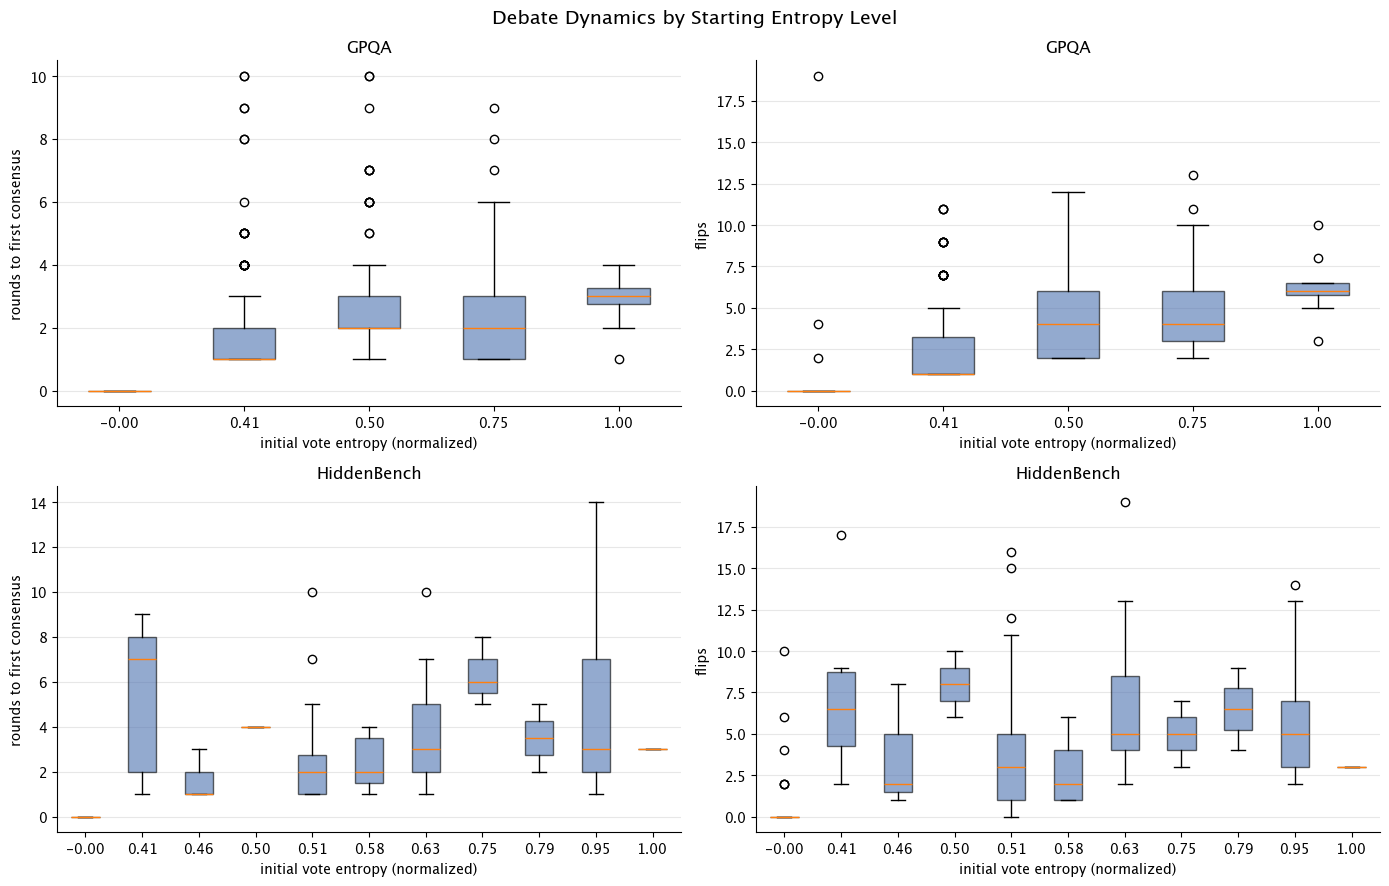

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, dataset in enumerate(['GPQA', 'HiddenBench']):
    sub = reps_df[reps_df['dataset'] == dataset]
    levels = sorted(sub['entropy_rounded'].unique())

    for col, (metric, label, converged_only) in enumerate([
        ('rounds_to_consensus', 'rounds to first consensus', True),
        ('flips', 'flips', False),
    ]):
        ax = axes[row, col]
        data = sub[sub['converged']] if converged_only else sub
        groups = [data[data['entropy_rounded'] == lv][metric].dropna().values for lv in levels]
        bp = ax.boxplot(groups, patch_artist=True,
                        labels=[f'{lv:.2f}' for lv in levels])
        for patch in bp['boxes']:
            patch.set(facecolor=TIER_COLORS[2], alpha=0.6)
        ax.set_xlabel('initial vote entropy (normalized)')
        ax.set_ylabel(label)
        ax.set_title(dataset, fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle('Debate Dynamics by Starting Entropy Level', fontsize=14)
plt.tight_layout()
plt.show()


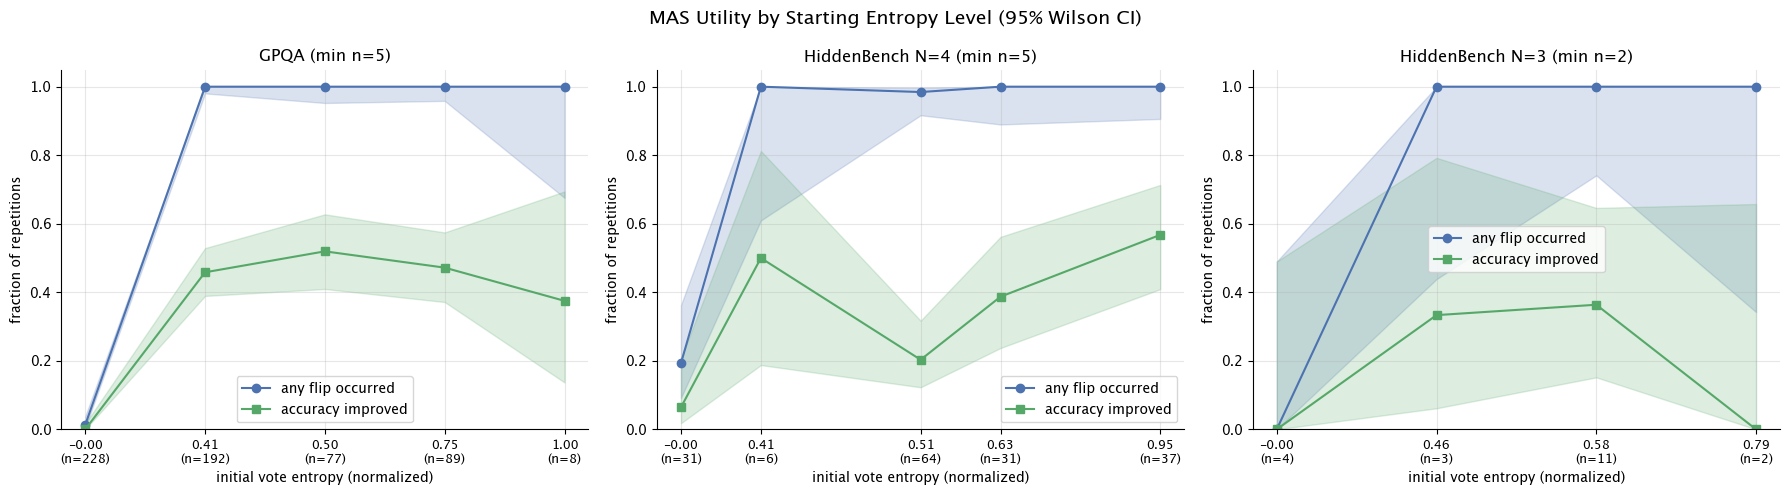

In [70]:
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return 0.0, 1.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

hb_n4_qids = {qid for qid, d in hb_raw.items() if d['N'] == 4}
hb_n3_qids = {qid for qid, d in hb_raw.items() if d['N'] == 3}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

subsets = [
    ('GPQA',            reps_df[reps_df['dataset'] == 'GPQA'],                                                5),
    ('HiddenBench N=4', reps_df[(reps_df['dataset'] == 'HiddenBench') & reps_df['qid'].isin(hb_n4_qids)],    5),
    ('HiddenBench N=3', reps_df[(reps_df['dataset'] == 'HiddenBench') & reps_df['qid'].isin(hb_n3_qids)],    2),
]

for ax, (title, sub, min_n) in zip(axes, subsets):
    levels = sorted(sub['entropy_rounded'].unique())

    flip_rates, helped_rates, ns, xs = [], [], [], []
    flip_lo, flip_hi, helped_lo, helped_hi = [], [], [], []

    for i, lv in enumerate(levels):
        grp = sub[sub['entropy_rounded'] == lv]
        n = len(grp)
        if n < min_n:
            continue

        ns.append(n); xs.append(i)
        k_flip   = grp['any_flip'].sum()
        k_helped = (grp['accuracy_delta'] > 0).sum()

        flip_rates.append(k_flip / n)
        helped_rates.append(k_helped / n)

        lo, hi = wilson_ci(k_flip, n)
        flip_lo.append(lo); flip_hi.append(hi)

        lo, hi = wilson_ci(k_helped, n)
        helped_lo.append(lo); helped_hi.append(hi)

    ax.plot(xs, flip_rates,   marker='o', label='any flip occurred', color='#4C72B0')
    ax.fill_between(xs, flip_lo, flip_hi, alpha=0.2, color='#4C72B0')

    ax.plot(xs, helped_rates, marker='s', label='accuracy improved', color='#55A868')
    ax.fill_between(xs, helped_lo, helped_hi, alpha=0.2, color='#55A868')

    ax.set_xticks(xs)
    ax.set_xticklabels([f'{levels[i]:.2f}\n(n={n})' for i, n in zip(xs, ns)], fontsize=9)
    ax.set_xlabel('initial vote entropy (normalized)')
    ax.set_ylabel('fraction of repetitions')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{title} (min n={min_n})', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('MAS Utility by Starting Entropy Level (95% Wilson CI)', fontsize=14)
plt.tight_layout()
plt.show()


**GPQA:** Once any initial disagreement exists (entropy > 0), debate always occurs (blue line = 100%).
However, accuracy only improves in ~45–52% of cases — the MAS exhibits a **herding effect**:
the majority position wins, which helps when the majority started correct but overrules the
minority even when it was right. The drop at entropy=1.0 is tentative (n=8).

**HiddenBench N=4:** Even at entropy=0, ~20% of reps still produce flips — hidden information
creates dynamics independent of starting diversity. Accuracy improvement peaks at the highest
entropy level (~57%), the opposite trend to GPQA.

**Key takeaway:** The value of starting diversity depends on whether diverse positions carry
independent information. In GPQA (symmetric information), diversity is mostly noise and the
MAS enforces majority conformity. In HiddenBench (asymmetric information), high starting
diversity means agents bring genuinely different private information into the debate, enabling
exploration of solution spaces that low-diversity starts would miss.

→ *Diverse starting positions are useful when agents have heterogeneous information,
not just heterogeneous uncertainty.*

In [67]:
from collections import Counter
print(Counter(d['N'] for d in hb_raw.values()))


Counter({4: 58, 3: 7})


## Motif Detection (R=3 proxy)

In [71]:
def detect_cascade(rep):
    traj = rep['trajectory']
    n_agents = len(traj[0]['phase_b'])
    for t in range(1, len(traj)):
        flips = sum(
            traj[t - 1]['phase_b'][ag]['vote'] != traj[t]['phase_b'][ag]['vote']
            for ag in range(n_agents)
        )
        if flips >= 2:
            return True
    return False

def detect_minority_wins(rep):
    traj = rep['trajectory']
    v0 = votes_at(rep, 0)
    vf = votes_at(rep, len(traj) - 1)
    if len(set(vf)) != 1:
        return False
    consensus = vf[0]
    return v0.count(consensus) < len(v0) / 2

def detect_backflip(rep):
    traj = rep['trajectory']
    n_agents = len(traj[0]['phase_b'])
    for ag in range(n_agents):
        seq = [traj[t]['phase_b'][ag]['vote'] for t in range(len(traj))]
        for i in range(2, len(seq)):
            if seq[i] == seq[i - 2] and seq[i] != seq[i - 1]:
                return True
    return False

motif_records = []
for dataset, raw, df in [('GPQA', gpqa_raw, gpqa_df), ('HiddenBench', hb_raw, hb_df)]:
    tier_map = dict(zip(df['qid'], df['tier']))
    for qid, d in raw.items():
        for i, rep in enumerate(d['repetitions']):
            motif_records.append({
                'dataset': dataset,
                'qid': qid,
                'rep': i,
                'tier': tier_map[qid],
                'cascade':       detect_cascade(rep),
                'minority_wins': detect_minority_wins(rep),
                'backflip':      detect_backflip(rep),
            })

motifs_df = pd.DataFrame(motif_records)

bistability = {
    'GPQA':        dict(zip(gpqa_df['qid'], gpqa_df['outcome_variance'])),
    'HiddenBench': dict(zip(hb_df['qid'],   hb_df['outcome_variance'])),
}

motif_cols = ['cascade', 'minority_wins', 'backflip']

print('Motif rates per dataset and tier (fraction of reps / questions with outcome variance)\n')
for dataset in ['GPQA', 'HiddenBench']:
    sub = motifs_df[motifs_df['dataset'] == dataset]
    n_q = len(raw := (gpqa_raw if dataset == 'GPQA' else hb_raw))
    n_bistable = sum(bistability[dataset].values())
    print(f'{dataset}  ({len(sub)} reps, {n_q} questions)')
    print(f'  bistability proxy (outcome_variance): {n_bistable}/{n_q} = {100*n_bistable/n_q:.1f}% of questions')
    for col in motif_cols:
        rate = sub[col].mean()
        n    = sub[col].sum()
        print(f'  {col:<15} {rate:.2f}  ({int(n)}/{len(sub)} reps)')
    print()

print('--- Per-tier breakdown (all datasets) ---')
for dataset in ['GPQA', 'HiddenBench']:
    sub = motifs_df[motifs_df['dataset'] == dataset]
    print(f'\n{dataset}')
    for tier in sorted(sub['tier'].unique()):
        t = sub[sub['tier'] == tier]
        rates = {c: t[c].mean() for c in motif_cols}
        n_q_tier = len(set(t['qid']))
        bist_rate = np.mean([bistability[dataset].get(qid, False)
                             for qid in t['qid'].unique()])
        print(f'  Tier {tier} (n_q={n_q_tier}, n_reps={len(t)}): '
              + '  '.join(f'{c}={rates[c]:.2f}' for c in motif_cols)
              + f'  bistability={bist_rate:.2f}')


Motif rates per dataset and tier (fraction of reps / questions with outcome variance)

GPQA  (594 reps, 198 questions)
  bistability proxy (outcome_variance): 83/198 = 41.9% of questions
  cascade         0.40  (240/594 reps)
  minority_wins   0.14  (85/594 reps)
  backflip        0.24  (144/594 reps)

HiddenBench  (195 reps, 65 questions)
  bistability proxy (outcome_variance): 40/65 = 61.5% of questions
  cascade         0.55  (108/195 reps)
  minority_wins   0.30  (59/195 reps)
  backflip        0.39  (77/195 reps)

--- Per-tier breakdown (all datasets) ---

GPQA
  Tier 0 (n_q=44, n_reps=132): cascade=0.00  minority_wins=0.00  backflip=0.00  bistability=0.00
  Tier 1 (n_q=34, n_reps=102): cascade=0.17  minority_wins=0.05  backflip=0.00  bistability=0.21
  Tier 2 (n_q=120, n_reps=360): cascade=0.62  minority_wins=0.22  backflip=0.40  bistability=0.63

HiddenBench
  Tier 0 (n_q=4, n_reps=12): cascade=0.00  minority_wins=0.00  backflip=0.00  bistability=0.00
  Tier 1 (n_q=3, n_reps=9):

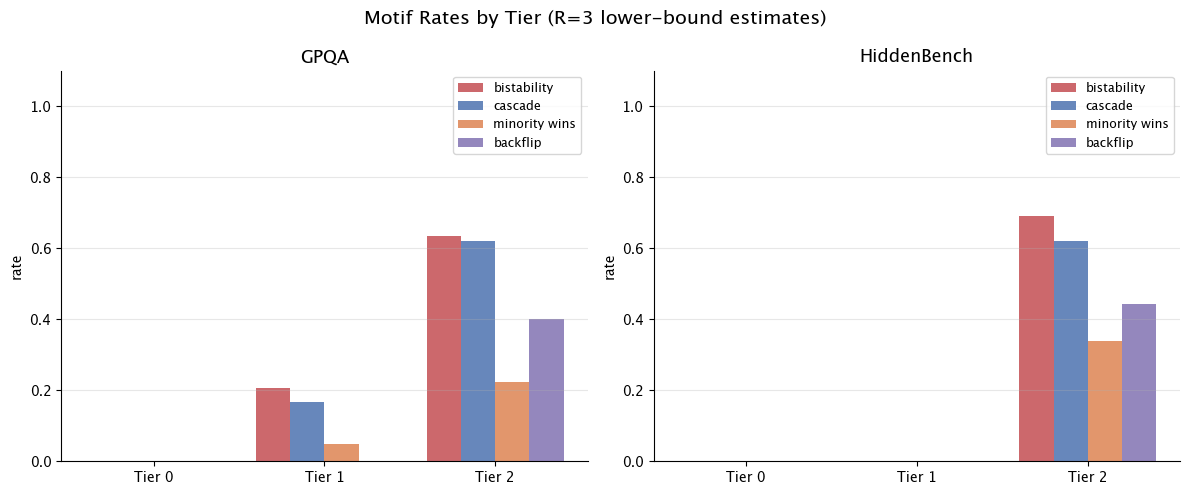

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df_q, raw) in zip(axes, [
    ('GPQA',        gpqa_df, gpqa_raw),
    ('HiddenBench', hb_df,   hb_raw),
]):
    sub = motifs_df[motifs_df['dataset'] == name]
    tiers = sorted(sub['tier'].unique())
    x = np.arange(len(tiers))
    n_motifs = len(motif_cols) + 1
    w = 0.8 / n_motifs
    colors = ['#C44E52', '#4C72B0', '#DD8452', '#8172B2']
    labels_plot = ['bistability', 'cascade', 'minority wins', 'backflip']

    for mi, (col, label, color) in enumerate(zip(
        ['_bistability'] + motif_cols,
        labels_plot,
        colors,
    )):
        rates = []
        for tier in tiers:
            if col == '_bistability':
                qids = sub[sub['tier'] == tier]['qid'].unique()
                rate = np.mean([bistability[name].get(qid, False) for qid in qids])
            else:
                t = sub[sub['tier'] == tier]
                rate = t[col].mean()
            rates.append(rate)
        offset = (mi - n_motifs / 2 + 0.5) * w
        ax.bar(x + offset, rates, w, label=label, color=color, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([f'Tier {t}' for t in tiers])
    ax.set_ylabel('rate')
    ax.set_ylim(0, 1.1)
    ax.set_title(name, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Motif Rates by Tier (R=3 lower-bound estimates)', fontsize=14)
plt.tight_layout()
plt.show()


In [74]:
gpqa_subset = sorted(gpqa_df[gpqa_df['tier'] == 2]['qid'].tolist())
hb_subset   = sorted(
    hb_df[(hb_df['tier'] == 2) & hb_df['qid'].isin(hb_n4_qids)]['qid'].tolist()
)

print(f'GPQA subset:              {len(gpqa_subset)} questions')
print(f'HiddenBench subset (N=4): {len(hb_subset)} questions')
print()
print(f'gpqa_subset = {gpqa_subset}')
print()
print(f'hb_subset   = {hb_subset}')


GPQA subset:              120 questions
HiddenBench subset (N=4): 51 questions

gpqa_subset = [1, 3, 5, 6, 7, 8, 9, 10, 12, 14, 15, 17, 18, 21, 23, 24, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 41, 42, 44, 47, 48, 50, 51, 52, 53, 54, 55, 56, 60, 61, 63, 64, 66, 67, 69, 70, 71, 73, 75, 79, 80, 81, 84, 85, 86, 88, 90, 91, 92, 94, 95, 98, 99, 102, 104, 109, 111, 113, 114, 115, 117, 118, 120, 121, 123, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 136, 138, 139, 140, 141, 143, 144, 145, 146, 147, 149, 152, 154, 155, 157, 159, 162, 163, 164, 166, 168, 169, 170, 172, 173, 175, 179, 180, 182, 183, 185, 186, 187, 189, 194]

hb_subset   = [0, 1, 2, 4, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 30, 31, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 64]


In [76]:
import json

subset_dir = ROOT / 'dataset'

(subset_dir / 'gpqa_subset_tier2.json').write_text(json.dumps(gpqa_subset))
(subset_dir / 'hiddenbench_subset_tier2_n4.json').write_text(json.dumps(hb_subset))

print(f'Saved gpqa_subset_tier2.json            ({len(gpqa_subset)} indices)')
print(f'Saved hiddenbench_subset_tier2_n4.json  ({len(hb_subset)} indices)')


Saved gpqa_subset_tier2.json            (120 indices)
Saved hiddenbench_subset_tier2_n4.json  (51 indices)


In [75]:
def inspect_question(qid, raw):
    d = raw[qid]
    gt = d['ground_truth']
    rows = []
    for i, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']
        v0 = votes_at(rep, 0)
        vf = votes_at(rep, len(traj) - 1)
        rows.append({
            'rep':    i,
            'start':  '→'.join(v0),
            'final':  '→'.join(vf),
            'rounds': len(traj),
            'flips':  count_flips(rep),
            'converged': len(set(vf)) == 1,
        })
    df = pd.DataFrame(rows).set_index('rep')
    print(f'  qid={qid}  gt={gt}  mean_rounds={df["rounds"].mean():.1f}  mean_flips={df["flips"].mean():.1f}')
    print(df.to_string())
    print()

print('=' * 60)
print('GPQA — Tier 2 subset')
print('=' * 60)
for qid in gpqa_subset:
    inspect_question(qid, gpqa_raw)

print('=' * 60)
print('HiddenBench — Tier 2 subset (N=4)')
print('=' * 60)
for qid in hb_subset:
    inspect_question(qid, hb_raw)


GPQA — Tier 2 subset
  qid=1  gt=B  mean_rounds=4.3  mean_flips=2.7
       start    final  rounds  flips  converged
rep                                            
0    B→D→D→B  B→B→B→B       4      2       True
1    C→B→B→B  B→B→B→B       5      5       True
2    B→B→B→A  B→B→B→B       4      1       True

  qid=3  gt=D  mean_rounds=6.0  mean_flips=5.3
       start    final  rounds  flips  converged
rep                                            
0    B→B→C→C  C→C→C→C       5      4       True
1    B→C→B→B  B→B→B→B       7      5       True
2    B→B→B→C  C→C→C→C       6      7       True

  qid=5  gt=C  mean_rounds=5.0  mean_flips=4.0
       start    final  rounds  flips  converged
rep                                            
0    D→B→B→D  C→C→C→C       6      8       True
1    C→C→C→C  C→C→C→C       4      0       True
2    C→C→D→D  D→D→D→D       5      4       True

  qid=6  gt=A  mean_rounds=6.7  mean_flips=6.3
       start    final  rounds  flips  converged
rep                 